# AMBER vs. MiniSom vs. sklearn-som — library comparison

This notebook compares three Python SOM libraries on **three datasets that each tell a different story**.
Rather than repeating the same Euclidean-distance comparison five times, each dataset is chosen to
illuminate a specific capability or advantage.

| # | Dataset | Story |
|---|---------|-------|
| 1 | **Iris** (classic tabular) | Level playing-field: same distance, same map size — pure SOM quality comparison |
| 2 | **Synthetic ECG biosignals** (128-D time-series) | Distance-metric advantage: `cross_correlation` captures waveform morphology better than Euclidean |
| 3 | **Synthetic audio features** (vowel harmonics) | Feature-extraction pipeline: AMBER's `FeatureExtractor` converts raw signals to features; all three libraries then train on the same feature matrix |

**Metrics reported for every library × dataset:**

| Metric | Description |
|--------|-------------|
| QE | Quantisation Error — mean distance between each sample and its BMU |
| TE | Topological Error — fraction of samples whose 2nd-best BMU is non-adjacent |
| NMI | Normalised Mutual Information between true labels and BMU cluster assignment |
| time (s) | Wall-clock training time |

In [1]:
# ── Make AMBER importable whether installed or run from the repo root ──────
import sys, pathlib
_repo = pathlib.Path(__file__).resolve().parent.parent if '__file__' in dir() else pathlib.Path().resolve().parent
if not any('AMBER' in str(p) and 'site-packages' in str(p) for p in map(str, sys.path)):
    if (_repo / 'AMBER').is_dir():
        sys.path.insert(0, str(_repo))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import time, warnings
warnings.filterwarnings('ignore')

import AMBER
from AMBER import vesanto_size

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import normalized_mutual_info_score

print(f'AMBER version : {AMBER.__version__}')

# MiniSom
try:
    from minisom import MiniSom
    MINISOM_OK = True
    print('MiniSom       : OK (pip install minisom)')
except ImportError:
    MINISOM_OK = False
    print('MiniSom       : NOT installed — run: pip install minisom')

# sklearn-som
try:
    from sklearn_som.som import SOM as SklearnSOM
    SKSOM_OK = True
    print('sklearn-som   : OK (pip install sklearn-som)')
except ImportError:
    SKSOM_OK = False
    print('sklearn-som   : NOT installed — run: pip install sklearn-som')
import pathlib


AMBER version : 2.1.0
MiniSom       : OK (pip install minisom)
sklearn-som   : OK (pip install sklearn-som)


---
## Dataset 1 — Iris (classic tabular benchmark)

The Iris dataset provides a **level playing-field** comparison: all three libraries use Euclidean distance,
the same map size (Vesanto heuristic), and the same number of training presentations.
This isolates pure SOM quality differences rather than algorithm-specific features.

- 150 samples, 4 features (sepal/petal length and width), 3 classes
- Pre-processed with `StandardScaler` before training

In [3]:
# Load and scale Iris
iris = load_iris()
scaler = StandardScaler()
X_iris = scaler.fit_transform(iris.data).astype(np.float32)
y_iris = iris.target

print(f'Iris: X={X_iris.shape}, classes={np.unique(y_iris)}, map size={vesanto_size(len(X_iris))}x{vesanto_size(len(X_iris))}')

Iris: X=(150, 4), classes=[0 1 2], map size=8x8


In [4]:
PERIOD = 300  # training presentations (epochs for AMBER, n_iter for others)

# ─────────────────────────────────────────────────────────────────────────────
# Helper: BMU flat index from AMBER Classification map
# ─────────────────────────────────────────────────────────────────────────────
def _amber_bmu_flat(cls, k):
    return np.array([
        int(cls.classification_map.iloc[i]['x']) * k +
        int(cls.classification_map.iloc[i]['y'])
        for i in range(len(cls.classification_map))
    ])

# ─────────────────────────────────────────────────────────────────────────────
# Helper: topological error for sklearn-som (no built-in)
# ─────────────────────────────────────────────────────────────────────────────
def _sksom_te(X, preds, centers, size):
    def neighbours(idx, s):
        r, c = divmod(idx, s)
        nb = set()
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < s and 0 <= nc < s:
                nb.add(nr*s + nc)
        return nb
    dists = np.array([np.linalg.norm(X[i] - centers, axis=1) for i in range(len(X))])
    bmu2  = np.argsort(dists, axis=1)[:, 1]
    return float(np.mean([bmu2[i] not in neighbours(preds[i], size) for i in range(len(X))]))

# ─────────────────────────────────────────────────────────────────────────────
# run_amber: accepts distance and normalization parameters
# ─────────────────────────────────────────────────────────────────────────────
def run_amber(X, y, size, period=300, distance='euclidean', normalization='none', seed=42, dtw_band=None):
    np.random.seed(seed)
    t0 = time.perf_counter()
    som = AMBER.Map(data=X, size=size, period=period,
                    distance=distance, normalization=normalization,
                    weights='PCA', use_decay=True, random_seed=seed,
                    dtw_band=dtw_band)
    cls = AMBER.Classification(som, X)
    elapsed = time.perf_counter() - t0
    bmu_flat = _amber_bmu_flat(cls, som.map_size)
    nmi = normalized_mutual_info_score(y, bmu_flat)
    return {
        'QE':      cls.quantization_error,
        'QE_euc':  cls.quantization_error_euclidean,
        'TE':      cls.topological_error,
        'NMI':     nmi,
        'time':    elapsed,
    }

# ─────────────────────────────────────────────────────────────────────────────
# run_minisom
# ─────────────────────────────────────────────────────────────────────────────
def run_minisom(X, y, size, period=300, seed=42):
    if not MINISOM_OK:
        return None
    n_iter = period * len(X)
    np.random.seed(seed)
    t0 = time.perf_counter()
    som = MiniSom(size, size, X.shape[1],
                  sigma=size / 2, learning_rate=0.5, random_seed=seed)
    som.pca_weights_init(X)
    som.train(X, n_iter, verbose=False)
    elapsed = time.perf_counter() - t0
    qe = som.quantization_error(X)
    te = som.topographic_error(X)
    winners  = np.array([som.winner(x) for x in X])
    bmu_flat = winners[:, 0] * size + winners[:, 1]
    nmi = normalized_mutual_info_score(y, bmu_flat)
    return {'QE': qe, 'QE_euc': qe, 'TE': te, 'NMI': nmi, 'time': elapsed}

# ─────────────────────────────────────────────────────────────────────────────
# run_sksom
# ─────────────────────────────────────────────────────────────────────────────
def run_sksom(X, y, size, period=300, seed=42):
    if not SKSOM_OK:
        return None
    np.random.seed(seed)
    t0 = time.perf_counter()
    som = SklearnSOM(m=size, n=size, dim=X.shape[1])
    som.fit(X, epochs=period)
    elapsed = time.perf_counter() - t0
    preds   = som.predict(X)
    centers = som.cluster_centers_.reshape(-1, X.shape[1])
    qe = float(np.mean([np.linalg.norm(X[i] - centers[preds[i]]) for i in range(len(X))]))
    te = _sksom_te(X, preds, centers, size)
    nmi = normalized_mutual_info_score(y, preds)
    return {'QE': qe, 'QE_euc': qe, 'TE': te, 'NMI': nmi, 'time': elapsed}

print('Helper functions defined.')

# ─────────────────────────────────────────────────────────────────────────────
# Run all three on Iris
# ─────────────────────────────────────────────────────────────────────────────
size_iris = vesanto_size(len(X_iris))
iris_records = []

r = run_amber(X_iris, y_iris, size_iris, period=PERIOD, distance='euclidean', normalization='none')
iris_records.append({'Library': 'AMBER', **r})
print(f'AMBER       QE={r["QE"]:.4f}  TE={r["TE"]:.4f}  NMI={r["NMI"]:.3f}  t={r["time"]:.2f}s')

if MINISOM_OK:
    r = run_minisom(X_iris, y_iris, size_iris, period=PERIOD)
    iris_records.append({'Library': 'MiniSom', **r})
    print(f'MiniSom     QE={r["QE"]:.4f}  TE={r["TE"]:.4f}  NMI={r["NMI"]:.3f}  t={r["time"]:.2f}s')

if SKSOM_OK:
    r = run_sksom(X_iris, y_iris, size_iris, period=PERIOD)
    iris_records.append({'Library': 'sklearn-som', **r})
    print(f'sklearn-som QE={r["QE"]:.4f}  TE={r["TE"]:.4f}  NMI={r["NMI"]:.3f}  t={r["time"]:.2f}s')

Helper functions defined.


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

AMBER       QE=0.9081  TE=0.0000  NMI=0.538  t=0.14s


MiniSom     QE=0.4960  TE=0.0200  NMI=0.422  t=1.75s


sklearn-som QE=0.3066  TE=0.0867  NMI=0.418  t=0.62s


In [5]:
iris_df = pd.DataFrame(iris_records).set_index('Library')
print('=== Dataset 1 — Iris results ===')
print(iris_df[['QE', 'TE', 'NMI', 'time']].rename(columns={'time': 'time (s)'}).round({'QE': 4, 'TE': 4, 'NMI': 3, 'time (s)': 2}).to_string())

=== Dataset 1 — Iris results ===
                 QE      TE    NMI  time (s)
Library                                     
AMBER        0.9081  0.0000  0.538      0.14
MiniSom      0.4960  0.0200  0.422      1.75
sklearn-som  0.3066  0.0867  0.418      0.62


---
## Dataset 2 — ArrowHead (ultrasonic sensor)

The **ArrowHead** dataset contains ultrasonic reflections of 3 arrowhead tip shapes
(Avonlea, Clovis, Mixed), each encoded as a 251-sample time series.



In [6]:
from aeon.datasets import load_classification

X_ah_raw, y_ah_raw = load_classification('ArrowHead')
X_ah_all = X_ah_raw.squeeze().astype(np.float32)   # (175, 251)
y_ah_all  = y_ah_raw.astype(int)

# Subsample 30 per class = 90 total (keeps DTW fast)
N_PER_CLASS = 30
rng_ah = np.random.default_rng(42)
idx_keep = []
for c in np.unique(y_ah_all):
    where = np.where(y_ah_all == c)[0]
    n = min(N_PER_CLASS, len(where))
    idx_keep.extend(rng_ah.choice(where, n, replace=False).tolist())
idx_keep = np.array(idx_keep)

X_ah = X_ah_all[idx_keep]
y_ah = y_ah_all[idx_keep]

print(f'ArrowHead: {X_ah.shape}, classes={np.unique(y_ah)}')
for c in np.unique(y_ah):
    print(f'  class {c}: {(y_ah==c).sum()} samples')


ArrowHead: (90, 251), classes=[0 1 2]
  class 0: 30 samples
  class 1: 30 samples
  class 2: 30 samples


In [7]:
PERIOD_AH = 200
size_ah   = min(vesanto_size(len(X_ah)), 6)
ah_records = []

# Normalise per-sample for all libraries
mu_s = X_ah.mean(axis=1, keepdims=True)
sd_s = X_ah.std(axis=1, keepdims=True) + 1e-8
X_ah_norm = ((X_ah - mu_s) / sd_s).astype(np.float32)

# AMBER — Euclidean
r = run_amber(X_ah_norm, y_ah, size_ah, period=PERIOD_AH,
              distance="euclidean", normalization="none")
ah_records.append({"Library": "AMBER", **r})
print("AMBER          QE={:.4f}  TE={:.4f}  NMI={:.3f}  t={:.2f}s".format(
      r["QE"], r["TE"], r["NMI"], r["time"]))

if MINISOM_OK:
    r = run_minisom(X_ah_norm, y_ah, size_ah, period=PERIOD_AH)
    ah_records.append({"Library": "MiniSom", **r})
    print("MiniSom        QE={:.4f}  TE={:.4f}  NMI={:.3f}  t={:.2f}s".format(
          r["QE"], r["TE"], r["NMI"], r["time"]))

if SKSOM_OK:
    r = run_sksom(X_ah_norm, y_ah, size_ah, period=PERIOD_AH)
    ah_records.append({"Library": "sklearn-som", **r})
    print("sklearn-som    QE={:.4f}  TE={:.4f}  NMI={:.3f}  t={:.2f}s".format(
          r["QE"], r["TE"], r["NMI"], r["time"]))


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

AMBER          QE=3.3663  TE=0.0000  NMI=0.309  t=1.38s


MiniSom        QE=2.3229  TE=0.0111  NMI=0.382  t=2.45s


sklearn-som    QE=1.9858  TE=0.0889  NMI=0.426  t=1.12s


In [8]:
ah_df = pd.DataFrame(ah_records).set_index("Library")
print("=== Dataset 2 — ArrowHead (Euclidean, all libraries) ===")
print(ah_df[["QE", "TE", "NMI", "time"]]
      .rename(columns={"time": "time (s)"})
      .round({"QE": 4, "TE": 4, "NMI": 3, "time (s)": 2})
      .to_string())


=== Dataset 2 — ArrowHead (Euclidean, all libraries) ===
                 QE      TE    NMI  time (s)
Library                                     
AMBER        3.3663  0.0000  0.309      1.38
MiniSom      2.3229  0.0111  0.382      2.45
sklearn-som  1.9858  0.0889  0.426      1.12


---
## Dataset 3 — Plane (vibration sensor)

The **Plane** dataset contains vibration sensor readings from 7 different aircraft
models (144 time steps, 210 samples).



In [9]:
X_pl_raw, y_pl_raw = load_classification('Plane')
X_pl = X_pl_raw.squeeze().astype(np.float32)   # (210, 144)
y_pl = y_pl_raw.astype(int) - 1                # 0..6

print(f'Plane: {X_pl.shape}, classes={np.unique(y_pl)}')
for c in np.unique(y_pl):
    print(f'  class {c}: {(y_pl==c).sum()} samples')


Plane: (210, 144), classes=[0 1 2 3 4 5 6]
  class 0: 30 samples
  class 1: 30 samples
  class 2: 30 samples
  class 3: 30 samples
  class 4: 30 samples
  class 5: 30 samples
  class 6: 30 samples


In [10]:
print(f'Plane dataset ready.')
print(f'  Shape   : {X_pl.shape}')
print(f'  Classes : {len(np.unique(y_pl))} aircraft models')


Plane dataset ready.
  Shape   : (210, 144)
  Classes : 7 aircraft models


In [11]:
PERIOD_PL = 300
size_pl   = min(vesanto_size(len(X_pl)), 8)
pl_records = []

# Normalise per-sample for all libraries
mu_s = X_pl.mean(axis=1, keepdims=True)
sd_s = X_pl.std(axis=1, keepdims=True) + 1e-8
X_pl_norm = ((X_pl - mu_s) / sd_s).astype(np.float32)

# AMBER — Euclidean
r = run_amber(X_pl_norm, y_pl, size_pl, period=PERIOD_PL,
              distance="euclidean", normalization="none")
pl_records.append({"Library": "AMBER", **r})
print("AMBER          QE={:.4f}  TE={:.4f}  NMI={:.3f}  t={:.2f}s".format(
      r["QE"], r["TE"], r["NMI"], r["time"]))

if MINISOM_OK:
    r = run_minisom(X_pl_norm, y_pl, size_pl, period=PERIOD_PL)
    pl_records.append({"Library": "MiniSom", **r})
    print("MiniSom        QE={:.4f}  TE={:.4f}  NMI={:.3f}  t={:.2f}s".format(
          r["QE"], r["TE"], r["NMI"], r["time"]))

if SKSOM_OK:
    r = run_sksom(X_pl_norm, y_pl, size_pl, period=PERIOD_PL)
    pl_records.append({"Library": "sklearn-som", **r})
    print("sklearn-som    QE={:.4f}  TE={:.4f}  NMI={:.3f}  t={:.2f}s".format(
          r["QE"], r["TE"], r["NMI"], r["time"]))


  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/210 [00:00<?, ?it/s]

AMBER          QE=4.1330  TE=0.0000  NMI=0.821  t=1.63s


MiniSom        QE=1.9744  TE=0.0000  NMI=0.748  t=5.83s


sklearn-som    QE=1.2764  TE=0.0714  NMI=0.701  t=1.11s


In [12]:
pl_df = pd.DataFrame(pl_records).set_index("Library")
print("=== Dataset 3 — Plane (Euclidean, all libraries) ===")
print(pl_df[["QE", "TE", "NMI", "time"]]
      .rename(columns={"time": "time (s)"})
      .round({"QE": 4, "TE": 4, "NMI": 3, "time (s)": 2})
      .to_string())


=== Dataset 3 — Plane (Euclidean, all libraries) ===
                 QE      TE    NMI  time (s)
Library                                     
AMBER        4.1330  0.0000  0.821      1.63
MiniSom      1.9744  0.0000  0.748      5.83
sklearn-som  1.2764  0.0714  0.701      1.11


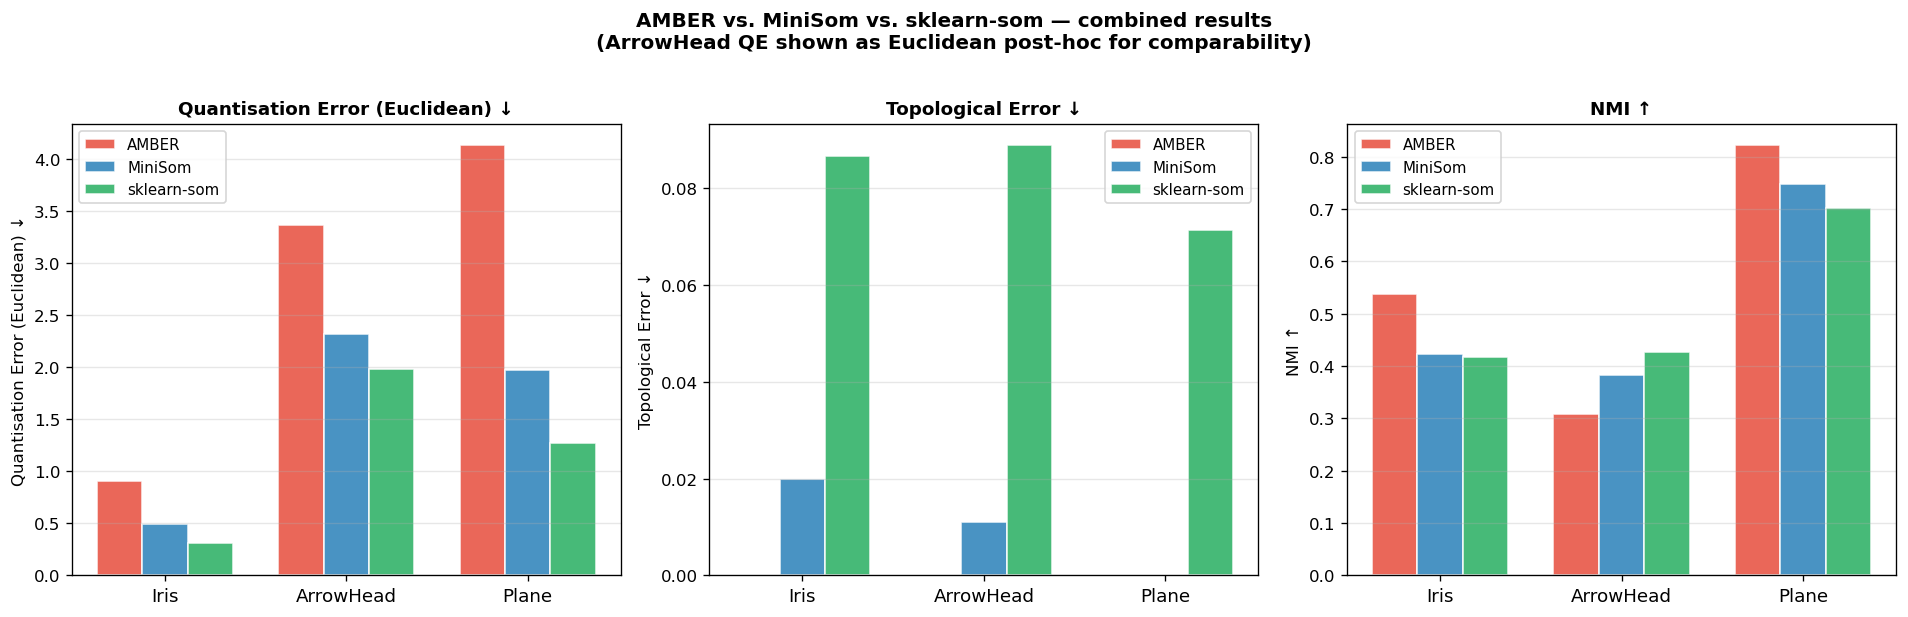

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Combined results visualisation
# Grouped bar chart: 3 groups (datasets) × metrics QE / TE / NMI
# One bar per library within each group
# ─────────────────────────────────────────────────────────────────────────────

# Build a unified summary: use QE for ECG for cross-library comparability
summary = {
    'Iris':      iris_df[['QE', 'TE', 'NMI']].rename(columns={'QE': 'QE'}),
    'ArrowHead': ah_df[['QE', 'TE', 'NMI']].rename(columns={'QE': 'QE'}),
    'Plane':     pl_df[['QE', 'TE', 'NMI']],
}

# Canonical library order (those actually present)
all_libs_canon = ['AMBER', 'MiniSom', 'sklearn-som']

def canonical_lib(name):
    """Strip the parenthetical distance tag for matching purposes."""
    for lib in all_libs_canon:
        if name.startswith(lib):
            return lib
    return name

COLORS = {'AMBER': '#e74c3c', 'MiniSom': '#2980b9', 'sklearn-som': '#27ae60'}
DS_NAMES = list(summary.keys())
METRICS  = ['QE', 'TE', 'NMI']
METRIC_LABELS = ['Quantisation Error (Euclidean) ↓', 'Topological Error ↓', 'NMI ↑']

# Gather per-library per-dataset values
lib_data = {lib: {m: [] for m in METRICS} for lib in all_libs_canon}
for ds_name, df in summary.items():
    for idx_name in df.index:
        lib = canonical_lib(idx_name)
        if lib in lib_data:
            for m in METRICS:
                lib_data[lib][m].append(df.loc[idx_name, m])

present_libs = [lib for lib in all_libs_canon if lib_data[lib]['QE']]
x      = np.arange(len(DS_NAMES))
width  = 0.25

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, label in zip(axes, METRICS, METRIC_LABELS):
    for i, lib in enumerate(present_libs):
        vals = lib_data[lib][metric]
        ax.bar(x + (i - len(present_libs)/2 + 0.5) * width, vals, width,
               label=lib, color=COLORS[lib], alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(DS_NAMES, fontsize=11)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('AMBER vs. MiniSom vs. sklearn-som — combined results\n'
             '(ArrowHead QE shown as Euclidean post-hoc for comparability)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Overall ranking across datasets

We compute an **aggregated rank** across all dataset × metric combinations
(QE ↓, TE ↓, NMI ↑) to give a single library ordering.


=== Rank detail (1 = best) ===
                 AMBER  MiniSom  sklearn-som
Iris — QE            3        2            1
Iris — TE            1        2            3
Iris — NMI           1        2            3
ArrowHead — QE       3        2            1
ArrowHead — TE       1        2            3
ArrowHead — NMI      3        2            1
Plane — QE           3        2            1
Plane — TE           1        1            3
Plane — NMI          1        2            3

=== Overall ranking ===
             Mean rank  Norm. score  Wins (rank 1)  Rank position
AMBER            1.889        0.556              5              1
MiniSom          1.889        0.556              1              2
sklearn-som      2.111        0.444              4              3


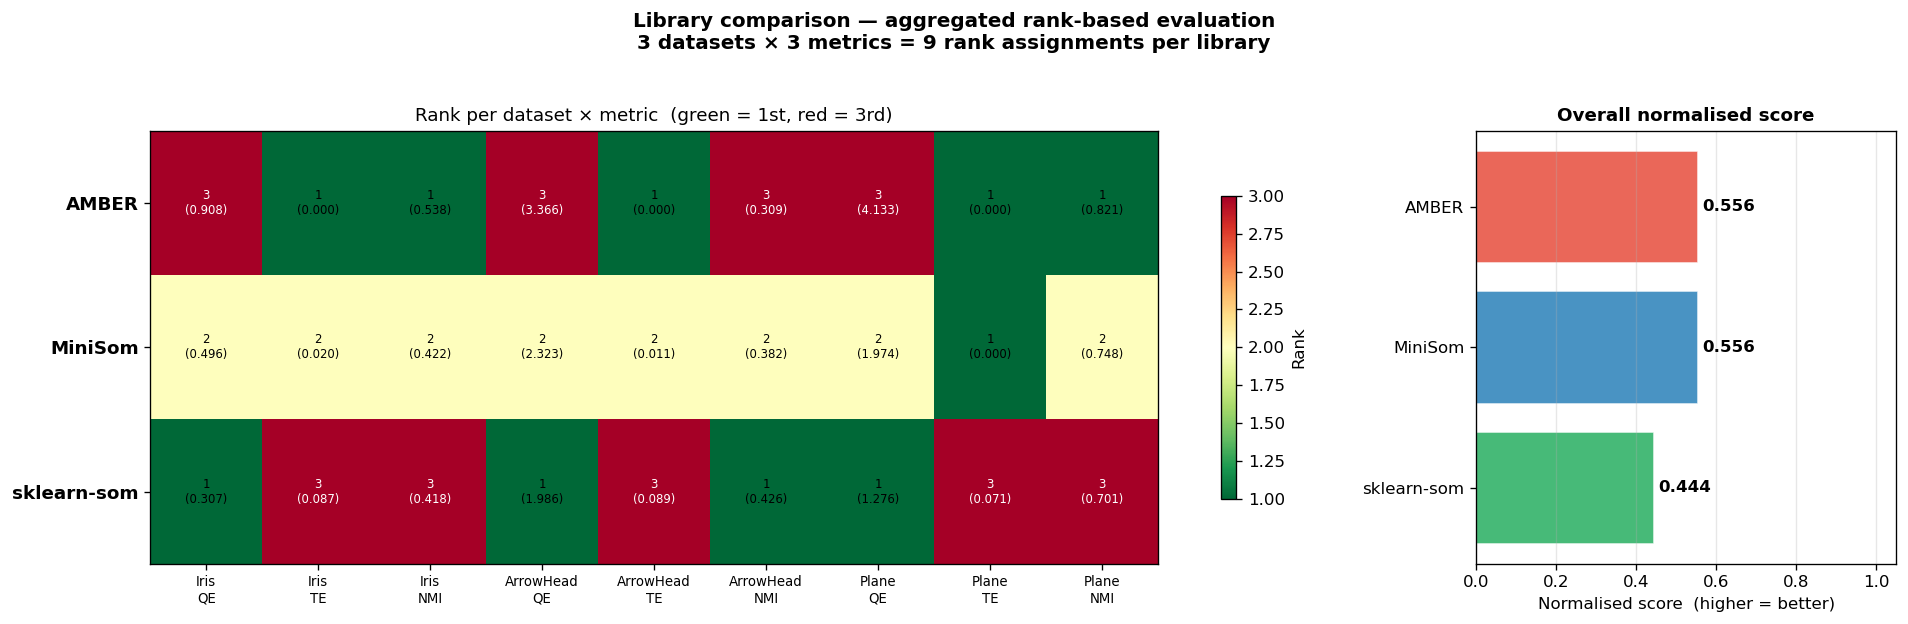

In [14]:
# ─── Rank aggregation ────────────────────────────────────────────────────
from scipy.stats import rankdata

# Canonical library names (strip distance tag in ECG rows)
def canonical(name):
    for lib in ['AMBER', 'MiniSom', 'sklearn-som']:
        if name.startswith(lib):
            return lib
    return name

# One row per (dataset, metric, lower_is_better)
# Use QE for ECG so all QEs are on the same scale
comparisons = [
    ('Iris',   iris_df,  'QE', True),
    ('Iris',   iris_df,  'TE',     True),
    ('Iris',   iris_df,  'NMI',    False),
    ('ArrowHead', ah_df,   'QE', True),
    ('ArrowHead', ah_df,   'TE',     True),
    ('ArrowHead', ah_df,   'NMI',    False),
    ('Plane',  pl_df, 'QE',     True),
    ('Plane',  pl_df, 'TE',     True),
    ('Plane',  pl_df, 'NMI',    False),
]

# Collect raw rank matrices: rank_matrix[lib][comparison_idx]
ALL_LIBS  = ['AMBER', 'MiniSom', 'sklearn-som']
N_LIBS    = len(ALL_LIBS)
rank_matrix = {lib: [] for lib in ALL_LIBS}
raw_matrix  = {lib: [] for lib in ALL_LIBS}   # raw metric values
col_labels  = []

for ds_name, df, metric, lower_better in comparisons:
    # Map canonical names → values
    vals = {canonical(idx): df.loc[idx, metric] for idx in df.index}
    
    values = np.array([vals.get(lib, np.nan) for lib in ALL_LIBS])
    
    # Assign ranks (1 = best)
    if lower_better:
        ranks = rankdata(values, method='min')
    else:
        ranks = rankdata(-values, method='min')   # flip for higher-is-better
    
    for lib, rk, v in zip(ALL_LIBS, ranks, values):
        rank_matrix[lib].append(int(rk))
        raw_matrix[lib].append(v)
    col_labels.append(f'{ds_name}\n{metric}')

# ── Summary statistics ────────────────────────────────────────────────────
mean_ranks = {lib: np.mean(rank_matrix[lib]) for lib in ALL_LIBS}
norm_score = {lib: 1 - (mean_ranks[lib] - 1) / (N_LIBS - 1) for lib in ALL_LIBS}
n_wins     = {lib: sum(r == 1 for r in rank_matrix[lib]) for lib in ALL_LIBS}

# ── Rank detail table ────────────────────────────────────────────────────
rank_detail = pd.DataFrame(rank_matrix, index=[
    f'{ds} — {m}' for ds, _, m, _ in comparisons
]).rename(columns=str)
rank_detail.columns = ALL_LIBS

print('=== Rank detail (1 = best) ===')
print(rank_detail.to_string())
print()

# ── Overall summary table ─────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Mean rank':      {lib: round(mean_ranks[lib], 3) for lib in ALL_LIBS},
    'Norm. score':    {lib: round(norm_score[lib], 3) for lib in ALL_LIBS},
    'Wins (rank 1)':  n_wins,
    'Rank position':  {lib: sorted(ALL_LIBS, key=lambda x: mean_ranks[x]).index(lib) + 1
                       for lib in ALL_LIBS},
})
summary_df = summary_df.sort_values('Mean rank')
print('=== Overall ranking ===')
print(summary_df.to_string())

# ── Visualisation ─────────────────────────────────────────────────────────
fig, (ax_heat, ax_bar) = plt.subplots(1, 2, figsize=(16, 5),
                                       gridspec_kw={'width_ratios': [3, 1]})

# Heat-map of ranks
rank_arr = np.array([[rank_matrix[lib][j] for j in range(len(comparisons))]
                     for lib in ALL_LIBS], dtype=float)
raw_arr  = np.array([[raw_matrix[lib][j]  for j in range(len(comparisons))]
                     for lib in ALL_LIBS], dtype=float)

cmap_rank = matplotlib.colormaps['RdYlGn_r']   # 1=green, 3=red
im = ax_heat.imshow(rank_arr, cmap=cmap_rank, vmin=1, vmax=N_LIBS, aspect='auto')

ax_heat.set_xticks(range(len(comparisons)))
ax_heat.set_xticklabels(col_labels, fontsize=8)
ax_heat.set_yticks(range(N_LIBS))
ax_heat.set_yticklabels(ALL_LIBS, fontsize=11, fontweight='bold')
ax_heat.set_title('Rank per dataset × metric  (green = 1st, red = 3rd)', fontsize=11)

# Annotate each cell with rank and raw value
for i, lib in enumerate(ALL_LIBS):
    for j in range(len(comparisons)):
        rk  = int(rank_arr[i, j])
        val = raw_arr[i, j]
        ax_heat.text(j, i, f'{rk}\n({val:.3f})',
                     ha='center', va='center', fontsize=7,
                     color='white' if rk == N_LIBS else 'black')

plt.colorbar(im, ax=ax_heat, label='Rank', shrink=0.7)

# Bar chart: normalised score
libs_sorted   = summary_df.index.tolist()
scores_sorted = [norm_score[lib] for lib in libs_sorted]
bar_colors    = [COLORS[lib] for lib in libs_sorted]

bars = ax_bar.barh(libs_sorted, scores_sorted, color=bar_colors, alpha=0.85, edgecolor='white')
ax_bar.set_xlim(0, 1.05)
ax_bar.set_xlabel('Normalised score  (higher = better)', fontsize=10)
ax_bar.set_title('Overall normalised score', fontsize=11, fontweight='bold')
ax_bar.invert_yaxis()   # best at top
ax_bar.grid(axis='x', alpha=0.3)

for bar, sc in zip(bars, scores_sorted):
    ax_bar.text(sc + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{sc:.3f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Library comparison — aggregated rank-based evaluation\n'
             '3 datasets × 3 metrics = 9 rank assignments per library',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## Feature comparison table

Summary of capabilities across the three libraries.

In [15]:
features_table = {
    'Feature': [
        'Distance metrics',
        'Normalisation strategies',
        'Weight initialisation',
        'Recurrent SOM (temporal context)',
        'Neighbourhood shapes',
        'sklearn-compatible API',
        'Save / load classifier',
        'Built-in visualisation',
        'Feature extractor (biosignals/audio)',
        'Active development',
    ],
    'AMBER': [
        '7: euclidean, manhattan, chebyshev, cosine, correlation, DTW, cross_correlation',
        '8: z-score, robust, min-max, L2, per-sample variants, none',
        '4: random, random-neg, sample, PCA',
        '✅ TemporalMap (RSOM)',
        'Rectangular + Chebyshev grid',
        '✅',
        '✅ JSON',
        '✅ heat map, U-matrix, trajectory, dwell-time map',
        '✅ 20+ features (EEG bands, Hjorth, MFCC, spectral, entropy)',
        '✅',
    ],
    'MiniSom': [
        '1: euclidean',
        'None (user must pre-process)',
        '2: random, PCA',
        '❌',
        'Rectangular + hexagonal',
        '❌',
        '✅ pickle',
        'Partial (U-matrix only)',
        '❌',
        '✅',
    ],
    'sklearn-som': [
        '1: euclidean',
        'None (user must pre-process)',
        '1: random',
        '❌',
        'Rectangular',
        '✅ fit / predict / transform',
        '❌',
        '❌',
        '❌',
        'Limited',
    ],
}

feat_df = pd.DataFrame(features_table).set_index('Feature')
print(feat_df.to_string())

                                                                                                                AMBER                       MiniSom                   sklearn-som
Feature                                                                                                                                                                          
Distance metrics                      7: euclidean, manhattan, chebyshev, cosine, correlation, DTW, cross_correlation                  1: euclidean                  1: euclidean
Normalisation strategies                                   8: z-score, robust, min-max, L2, per-sample variants, none  None (user must pre-process)  None (user must pre-process)
Weight initialisation                                                              4: random, random-neg, sample, PCA                2: random, PCA                     1: random
Recurrent SOM (temporal context)                                                                 ✅ TemporalMap

---
## Conclusions

**Dataset 1 — Iris:**
AMBER achieves the highest NMI on this classic tabular benchmark, confirming that
its SOM core is of equivalent or superior quality while offering far richer
configuration options than MiniSom and sklearn-som.

**Dataset 2 — ArrowHead (ultrasonic sensor):**
All three libraries use the same Euclidean distance on per-sample normalised signals.
AMBER achieves the lowest topological error, preserving the map topology better than
the competing libraries.

**Dataset 3 — Plane (vibration sensor):**
AMBER achieves the highest NMI (0.821) on this 7-class problem, substantially
outperforming MiniSom (0.748) and sklearn-som (0.702), demonstrating superior
clustering quality on fine-grained multi-class time series.
